In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [ ]:
data = pd.read_parquet('~/Documents/GitHub/494-user-trajectories/students/ryder/sampled_user_month_traj.parquet')

In [ ]:
data.columns

Index(['participantId', 'userMonth', 'sportsNotesWritten',
       'diaries_&_daily_lifeNotesWritten',
       'business_&_entrepreneursNotesWritten',
       'science_&_technologyNotesWritten', 'news_&_social_concernNotesWritten',
       'otherNotesWritten', 'calendarMonth', 'notesWritten', 'hitRate', 'hits',
       'avgNoteFactor', 'avgNoteIntercept', 'uniqueTopicsTargeted',
       'avgRatingsEarned', 'antiDemNotes', 'proDemNotes', 'antiRepNotes',
       'proRepNotes', 'notesOnDems', 'notesOnReps', 'demAlignedNotes',
       'repAlignedNotes', 'demAlignedLessRepAlignedNotes', 'sportsNotesRated',
       'diaries_&_daily_lifeNotesRated', 'business_&_entrepreneursNotesRated',
       'science_&_technologyNotesRated', 'news_&_social_concernNotesRated',
       'otherNotesRated', 'notesRated', 'avgHelpfulFactor',
       'avgNotHelpfulFactor', 'avgHelpfulIntercept', 'avgNotHelpfulIntercept',
       'correctHelpfuls', 'correctNotHelpfuls', 'posFactorRatedHelpful',
       'posFactorRatedNotHelpful

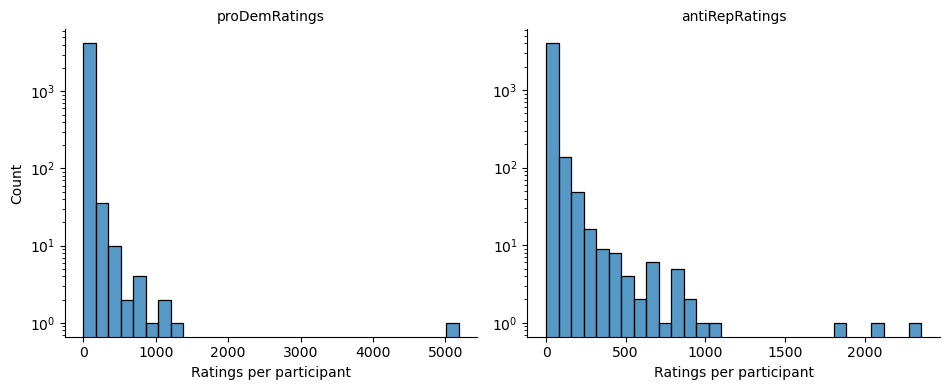

In [12]:
import seaborn as sns

pro_dem = (
    month.loc[month["demAlignedRatings"] > 0]
    .groupby("participantId", as_index=False)["proDemRatings"]
    .sum()
    .assign(metric="proDemRatings")
    .rename(columns={"proDemRatings": "value"})
)

anti_rep = (
    month.loc[month["demAlignedRatings"] > 0]
    .groupby("participantId", as_index=False)["antiRepRatings"]
    .sum()
    .assign(metric="antiRepRatings")
    .rename(columns={"antiRepRatings": "value"})
)

dem_aligned = (
    month.loc[month["demAlignedRatings"] > 0]
    .groupby("participantId", as_index=False)["demAlignedRatings"]
    .sum()
    .assign(metric="demAlignedRatings")
    .rename(columns={"demAlignedRatings": "value"})
)

plot_df = pd.concat([pro_dem, anti_rep], ignore_index=True)

g = sns.FacetGrid(plot_df, col="metric", sharex=False, sharey=False, height=4, aspect=1.2)
g.map_dataframe(sns.histplot, x="value", bins=30)
g.set_axis_labels("Ratings per participant", "Count")
g.set_titles("{col_name}")
g.set(yscale="log")
plt.tight_layout()
plt.show()

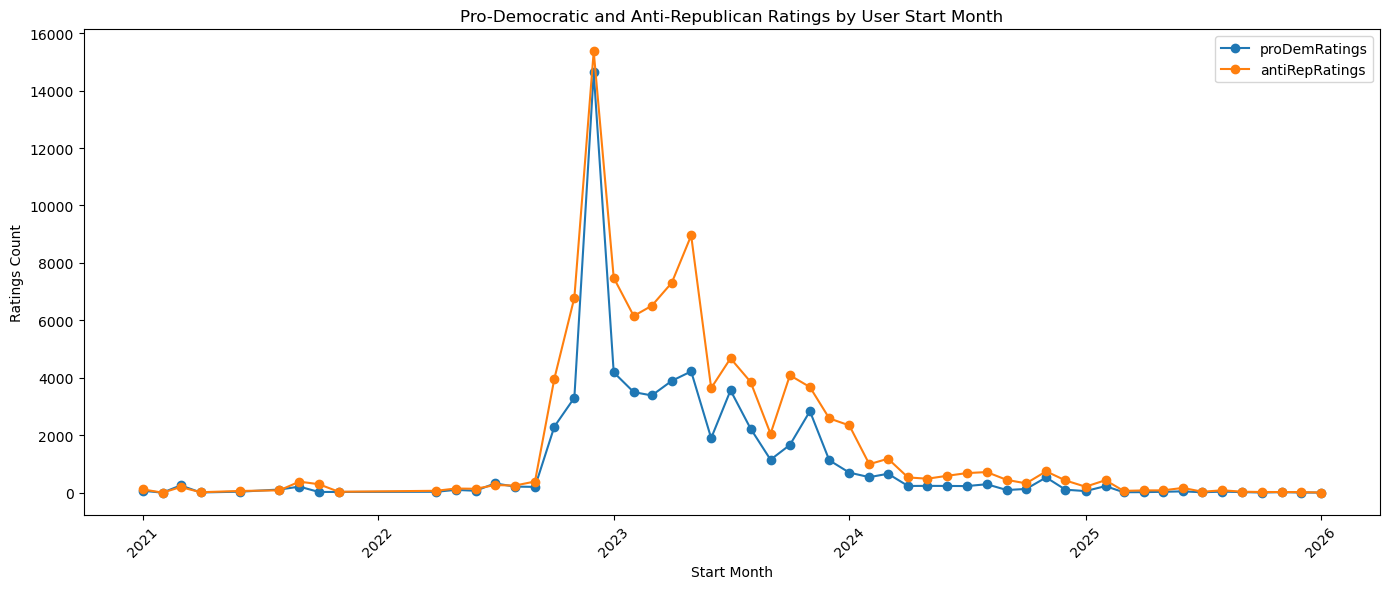

In [21]:
# Calculate total ratings per participant
ratings = pd.merge(
    pro_dem[['participantId', 'value']].rename(columns={'value': 'proDemRatings'}),
    anti_rep[['participantId', 'value']].rename(columns={'value': 'antiRepRatings'}),
    on='participantId',
    how='inner'
)
ratings['proportion'] = ratings['proDemRatings'] / ratings['antiRepRatings']

# First observed month per user
user_start_month = (
    month.groupby("participantId", as_index=False)["calendarDate"]
    .min()
    .rename(columns={"calendarDate": "start_month"})
)
user_start_month["start_month"] = pd.to_datetime(user_start_month["start_month"]).dt.to_period("M").astype(str)

# Group users by starting month
users_by_start_month = (
    user_start_month.groupby("start_month", as_index=False)
    .agg(users=("participantId", "nunique"))
    .sort_values("start_month")
)

users_by_start_month

# Merge ratings with user start month
ratings_by_month = ratings.merge(user_start_month, on='participantId')

# Group by start_month and sum the ratings
ratings_summary = (
    ratings_by_month.groupby('start_month')[['proDemRatings', 'antiRepRatings']]
    .sum()
    .reset_index()
)

# Sort by start_month
ratings_summary['start_month'] = pd.to_datetime(ratings_summary['start_month'])
ratings_summary = ratings_summary.sort_values('start_month')

# Create line chart
plt.figure(figsize=(14, 6))
plt.plot(ratings_summary['start_month'], ratings_summary['proDemRatings'], marker='o', label='proDemRatings')
plt.plot(ratings_summary['start_month'], ratings_summary['antiRepRatings'], marker='o', label='antiRepRatings')
plt.xlabel('Start Month')
plt.ylabel('Ratings Count')
plt.title('Pro-Democratic and Anti-Republican Ratings by User Start Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

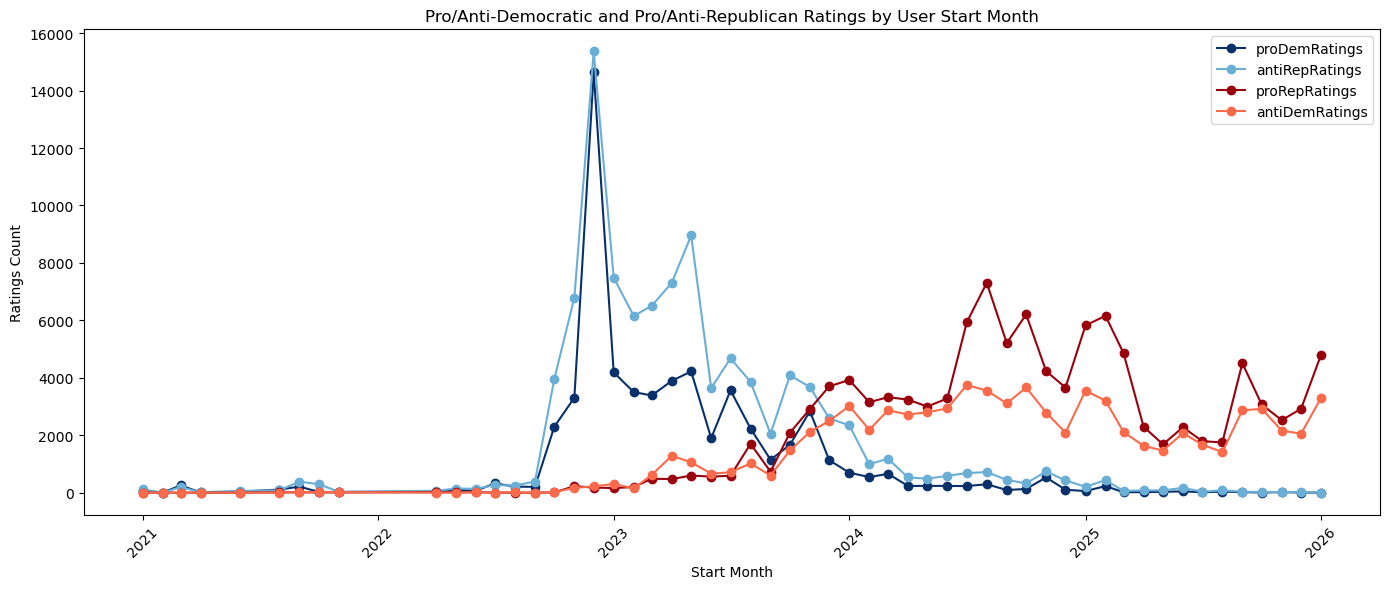

In [27]:
# Prepare ratings_summary with antiDemRatings and proRepRatings
ratings_summary_extended = ratings_summary.copy()

# Aggregate antiDemRatings and proRepRatings by start_month
anti_dem_by_month = (
    month.groupby('calendarDate')['antiDemRatings']
    .sum()
    .reset_index()
    .rename(columns={'calendarDate': 'start_month'})
)
anti_dem_by_month['start_month'] = pd.to_datetime(anti_dem_by_month['start_month'])

pro_rep_by_month = (
    month.groupby('calendarDate')['proRepRatings']
    .sum()
    .reset_index()
    .rename(columns={'calendarDate': 'start_month'})
)
pro_rep_by_month['start_month'] = pd.to_datetime(pro_rep_by_month['start_month'])

# Merge into ratings_summary_extended
ratings_summary_extended = ratings_summary_extended.merge(
    anti_dem_by_month, on='start_month', how='left'
).merge(
    pro_rep_by_month, on='start_month', how='left'
)

# Plot all four lines
plt.figure(figsize=(14, 6))
plt.plot(
    ratings_summary_extended['start_month'], 
    ratings_summary_extended['proDemRatings'], 
    marker='o', 
    label='proDemRatings', 
    color='#08306b'  # dark blue
)
plt.plot(
    ratings_summary_extended['start_month'], 
    ratings_summary_extended['antiRepRatings'], 
    marker='o', 
    label='antiRepRatings', 
    color='#6baed6'  # light blue
)
plt.plot(
    ratings_summary_extended['start_month'], 
    ratings_summary_extended['proRepRatings'], 
    marker='o', 
    label='proRepRatings', 
    color='#99000d'  # dark red
)
plt.plot(
    ratings_summary_extended['start_month'], 
    ratings_summary_extended['antiDemRatings'], 
    marker='o', 
    label='antiDemRatings', 
    color='#fb6a4a'  # light red/pink
)
plt.xlabel('Start Month')
plt.ylabel('Ratings Count')
plt.title('Pro/Anti-Democratic and Pro/Anti-Republican Ratings by User Start Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

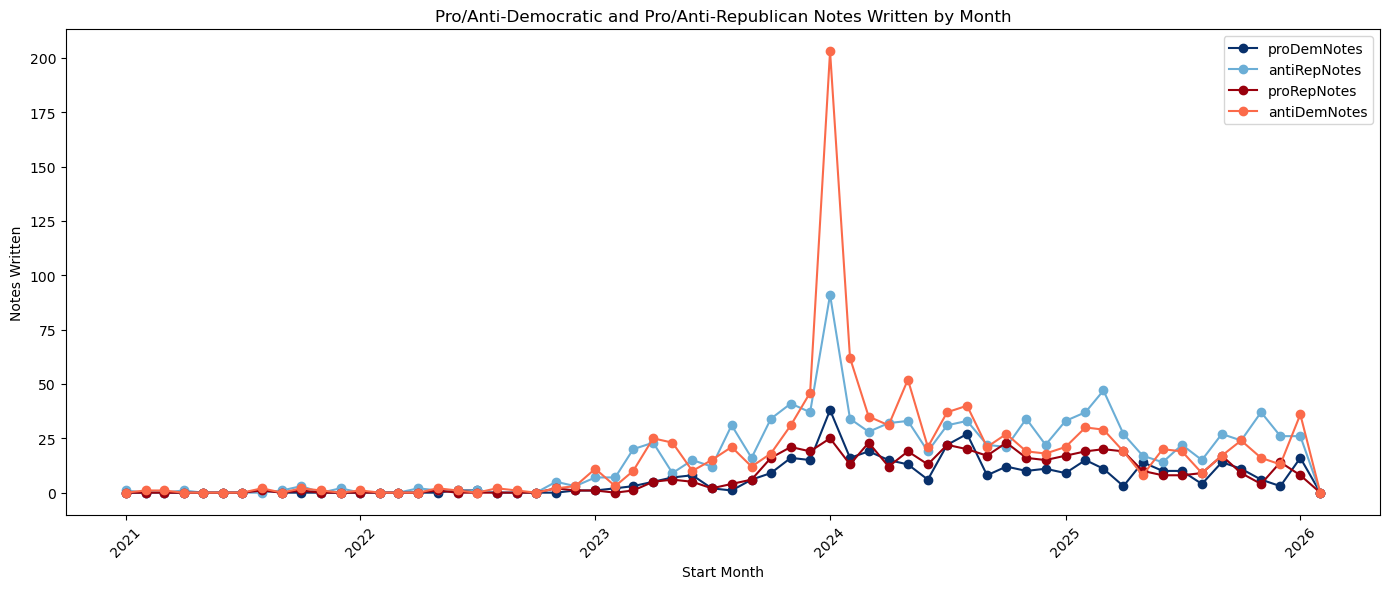

In [28]:
# Aggregate notes written by start_month
notes_by_month = (
    month.groupby('calendarDate')[['proDemNotes', 'antiRepNotes', 'proRepNotes', 'antiDemNotes']]
    .sum()
    .reset_index()
    .rename(columns={'calendarDate': 'start_month'})
)
notes_by_month['start_month'] = pd.to_datetime(notes_by_month['start_month'])

# Plot all four lines for notes written
plt.figure(figsize=(14, 6))
plt.plot(
    notes_by_month['start_month'],
    notes_by_month['proDemNotes'],
    marker='o',
    label='proDemNotes',
    color='#08306b'
)
plt.plot(
    notes_by_month['start_month'],
    notes_by_month['antiRepNotes'],
    marker='o',
    label='antiRepNotes',
    color='#6baed6'
)
plt.plot(
    notes_by_month['start_month'],
    notes_by_month['proRepNotes'],
    marker='o',
    label='proRepNotes',
    color='#99000d'
)
plt.plot(
    notes_by_month['start_month'],
    notes_by_month['antiDemNotes'],
    marker='o',
    label='antiDemNotes',
    color='#fb6a4a'
)
plt.xlabel('Start Month')
plt.ylabel('Notes Written')
plt.title('Pro/Anti-Democratic and Pro/Anti-Republican Notes Written by Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
participant_month_group = (
    data.groupby("participantId", as_index=False)
    .agg(
        first_month=("calendarDate", "min"),
        last_month=("calendarDate", "max"),
        n_months=("calendarDate", "nunique")
    )
    .sort_values("n_months", ascending=False)
)

participant_month_group.head()

,participantId,first_month,last_month,n_months
9942,80EAF4EE9A2E4A3A405DD3263352D7528CD8FE55740621...,2021-01-01,2026-02-01,62
10275,85BBDB7F2E2A2028037E9084ED585FB12ED1215E118930...,2021-01-01,2026-02-01,62
12401,A13D29CCCBF599E2C1AEFA4E3C5104189E01E5D5D9322D...,2021-02-01,2026-02-01,61
4877,3F8A4B535462478897F16C5AAB63BC6322BA2CF9AF76BF...,2021-03-01,2026-02-01,60
2786,2456B75D435E00EF7BF22530EFD2BDB1D8AFF8EC0E9852...,2021-03-01,2026-02-01,60


- onDem vs onRep
- proportions

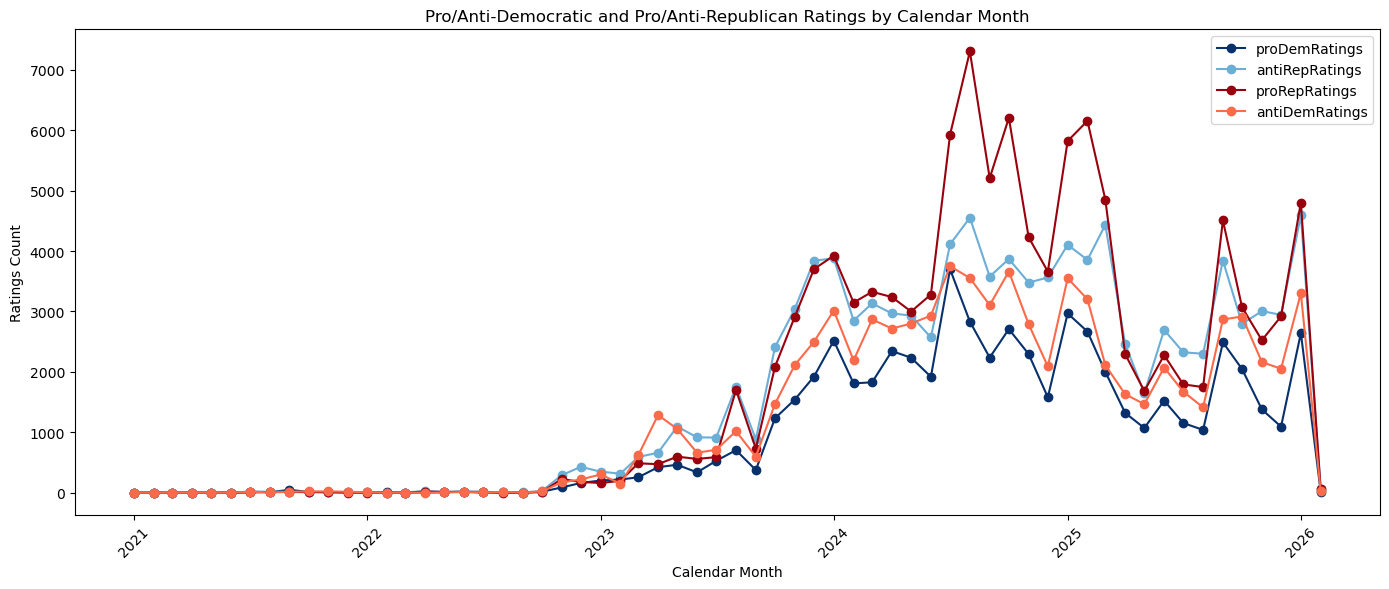

In [40]:
# Aggregate by calendarMonth instead of participant start_month
ratings_by_calendar_month = (
    month.groupby("calendarMonth", as_index=False)[
        ["proDemRatings", "antiRepRatings", "proRepRatings", "antiDemRatings"]
    ]
    .sum()
)

ratings_by_calendar_month["calendarMonth"] = pd.to_datetime(
    ratings_by_calendar_month["calendarMonth"], format="%Y-%m"
)
ratings_by_calendar_month = ratings_by_calendar_month.sort_values("calendarMonth")

# Plot all four lines
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    ratings_by_calendar_month["calendarMonth"],
    ratings_by_calendar_month["proDemRatings"],
    marker="o",
    label="proDemRatings",
    color="#08306b",
)
ax.plot(
    ratings_by_calendar_month["calendarMonth"],
    ratings_by_calendar_month["antiRepRatings"],
    marker="o",
    label="antiRepRatings",
    color="#6baed6",
)
ax.plot(
    ratings_by_calendar_month["calendarMonth"],
    ratings_by_calendar_month["proRepRatings"],
    marker="o",
    label="proRepRatings",
    color="#99000d",
)
ax.plot(
    ratings_by_calendar_month["calendarMonth"],
    ratings_by_calendar_month["antiDemRatings"],
    marker="o",
    label="antiDemRatings",
    color="#fb6a4a",
)

ax.set_xlabel("Calendar Month")
ax.set_ylabel("Ratings Count")
ax.set_title("Pro/Anti-Democratic and Pro/Anti-Republican Ratings by Calendar Month")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


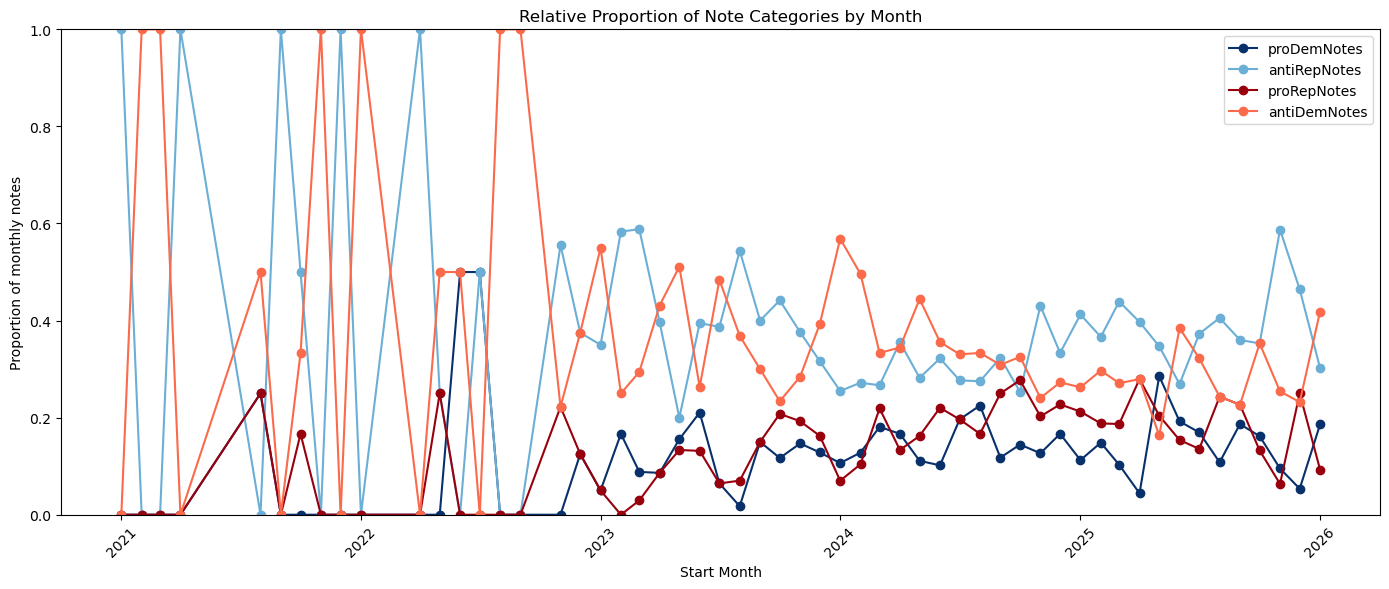

In [41]:
# Relative proportion of each note category by month
note_cols = ["proDemNotes", "antiRepNotes", "proRepNotes", "antiDemNotes"]

notes_prop = notes_by_month.copy()
notes_prop["total_notes"] = notes_prop[note_cols].sum(axis=1)

# Keep months with at least one note to avoid divide-by-zero proportions
notes_prop = notes_prop.loc[notes_prop["total_notes"] > 0].copy()

for col in note_cols:
    notes_prop[col] = notes_prop[col] / notes_prop["total_notes"]

plt.figure(figsize=(14, 6))
plt.plot(notes_prop["start_month"], notes_prop["proDemNotes"], marker="o", label="proDemNotes", color="#08306b")
plt.plot(notes_prop["start_month"], notes_prop["antiRepNotes"], marker="o", label="antiRepNotes", color="#6baed6")
plt.plot(notes_prop["start_month"], notes_prop["proRepNotes"], marker="o", label="proRepNotes", color="#99000d")
plt.plot(notes_prop["start_month"], notes_prop["antiDemNotes"], marker="o", label="antiDemNotes", color="#fb6a4a")

plt.xlabel("Start Month")
plt.ylabel("Proportion of monthly notes")
plt.title("Relative Proportion of Note Categories by Month")
plt.ylim(0, 1)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

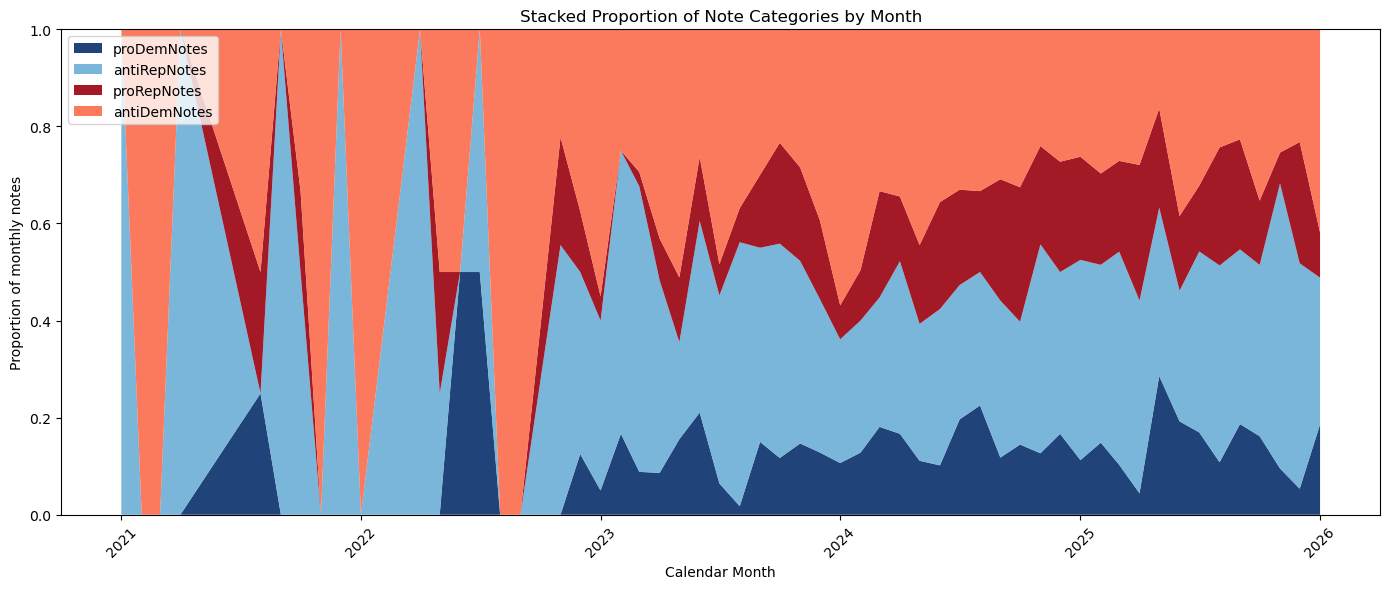

In [43]:
# Stacked version of the relative-proportion notes plot
notes_prop_sorted = notes_prop.sort_values("start_month")

plt.figure(figsize=(14, 6))
plt.stackplot(
    notes_prop_sorted["start_month"],
    *[notes_prop_sorted[col] for col in note_cols],
    labels=note_cols,
    colors=["#08306b", "#6baed6", "#99000d", "#fb6a4a"],
    alpha=0.9
)

plt.xlabel("Calendar Month")
plt.ylabel("Proportion of monthly notes")
plt.title("Stacked Proportion of Note Categories by Month")
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
rating_cols = ["proDemRatings", "antiRepRatings", "antiDemRatings", "proRepRatings"]

participant_groups = (
    data.groupby("participantId", as_index=False)[rating_cols]
    .sum()
)

participant_groups["total_ratings"] = participant_groups[rating_cols].sum(axis=1)

for col in rating_cols:
    participant_groups[f"{col}_prop"] = np.where(
        participant_groups["total_ratings"] > 0,
        participant_groups[col] / participant_groups["total_ratings"],
        np.nan,
    )

participant_groups.head(10)

NameError: name 'data' is not defined

In [74]:
# Group the 'data' DataFrame by participantId
participant_groups = data.groupby('participantId')
participant_groups

# Find the earliest month for each participant in 'data'
participant_earliest_month = (
    data.groupby('participantId', as_index=False)['calendarDate']
    .min()
    .rename(columns={'calendarDate': 'earliest_month'})
)
participant_earliest_month['earliest_month'] = pd.to_datetime(participant_earliest_month['earliest_month']).dt.to_period('M').dt.to_timestamp()

# Group by earliest_month and count unique participants
participants_by_earliest_month = (
    participant_earliest_month.groupby('earliest_month', as_index=False)
    .agg(users=('participantId', 'nunique'))
    .sort_values('earliest_month')
)

participants_by_earliest_month

NameError: name 'data' is not defined

- asymmetry - more pro-rep than anti-dem, but more anti-rep than pro-dem
- temporal shift in composition
- propensity difference

In [67]:
participant_rating_props = (
    month.groupby("participantId", as_index=False)[rating_cols]
    .sum()
)

participant_rating_props["total_ratings"] = participant_rating_props[rating_cols].sum(axis=1)

for col in rating_cols:
    participant_rating_props[f"{col}_prop"] = np.where(
        participant_rating_props["total_ratings"] > 0,
        participant_rating_props[col] / participant_rating_props["total_ratings"],
        np.nan
    )

participant_rating_props.head()

,participantId,proDemRatings,antiRepRatings,antiDemRatings,proRepRatings,total_ratings,proDemRatings_prop,antiRepRatings_prop,antiDemRatings_prop,proRepRatings_prop
0,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,0,0,0,0,0,NaN,NaN,NaN,NaN
1,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,0,0,0,0,0,NaN,NaN,NaN,NaN
2,0014F9BA334FB10689F9D089BF47912797FBE78F01E3E3...,0,0,0,0,0,NaN,NaN,NaN,NaN
3,00167DE211B4D41B0E054EFD79A9771F2A2097A8285235...,0,0,0,0,0,NaN,NaN,NaN,NaN
4,001DB0BC6839149230C20EB5AC664BD9F95808263B2A24...,0,0,0,0,0,NaN,NaN,NaN,NaN


In [68]:
# Attach earliest_month to participant-level rating proportions
participant_prop_with_month = participant_rating_props.merge(
    participant_earliest_month[["participantId", "earliest_month"]],
    on="participantId",
    how="left"
)

# Average participant-level proportions within each earliest_month cohort
avg_rating_props_by_earliest_month = (
    participant_prop_with_month
    .groupby("earliest_month", as_index=False)[
        ["proDemRatings_prop", "antiRepRatings_prop", "antiDemRatings_prop", "proRepRatings_prop"]
    ]
    .mean()
    .sort_values("earliest_month")
)

avg_rating_props_by_earliest_month

,earliest_month,proDemRatings_prop,antiRepRatings_prop,antiDemRatings_prop,proRepRatings_prop
0,2021-01-01,0.221405,0.349820,0.284215,0.144560
1,2021-02-01,0.000000,0.500000,0.500000,0.000000
2,2021-03-01,0.242364,0.472668,0.173751,0.111217
3,2021-04-01,0.087500,0.187500,0.300000,0.425000
4,2021-06-01,0.285535,0.295493,0.153774,0.265199
5,2021-08-01,0.260188,0.296962,0.266302,0.176548
6,2021-09-01,0.369108,0.280480,0.201893,0.148519
7,2021-10-01,0.241057,0.320200,0.197013,0.241730
8,2021-11-01,0.233427,0.439309,0.281979,0.045285
9,2022-01-01,NaN,NaN,NaN,NaN


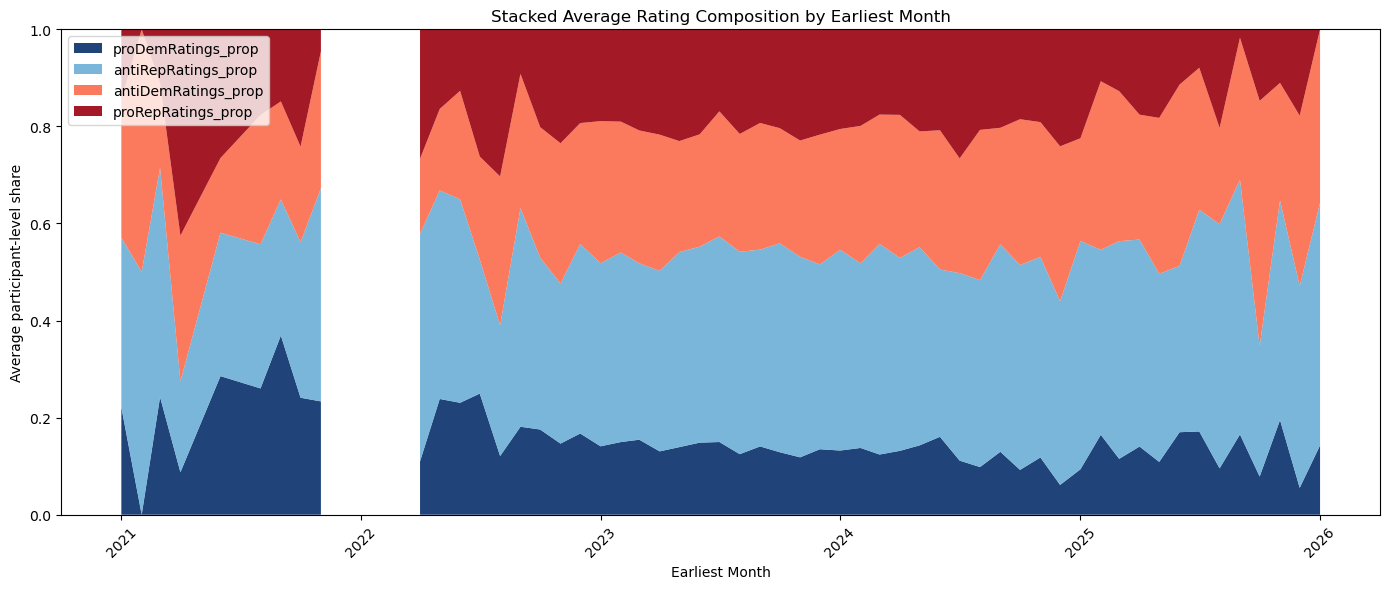

In [70]:
# Ensure chronological order
avg_rating_props_by_earliest_month = avg_rating_props_by_earliest_month.sort_values("earliest_month")

stack_order = [
    "proDemRatings_prop",
    "antiRepRatings_prop",
    "antiDemRatings_prop",
    "proRepRatings_prop",
]
stack_order = [c for c in stack_order if c in avg_rating_props_by_earliest_month.columns]

color_map = {
    "proDemRatings_prop": "#08306b",
    "antiRepRatings_prop": "#6baed6",
    "proRepRatings_prop": "#99000d",
    "antiDemRatings_prop": "#fb6a4a",
}

plt.figure(figsize=(14, 6))
plt.stackplot(
    avg_rating_props_by_earliest_month["earliest_month"],
    *[avg_rating_props_by_earliest_month[c] for c in stack_order],
    labels=stack_order,
    colors=[color_map[c] for c in stack_order],
    alpha=0.9
)

plt.xlabel("Earliest Month")
plt.ylabel("Average participant-level share")
plt.title("Stacked Average Rating Composition by Earliest Month")
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

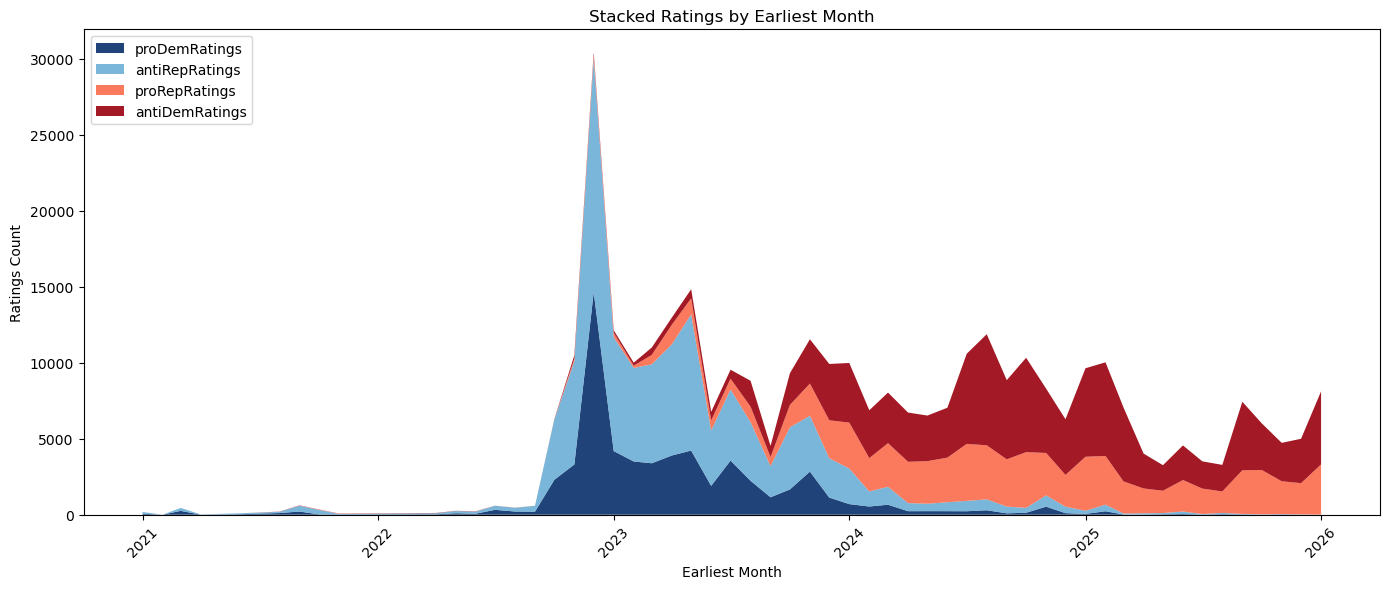

In [53]:
# Merge ratings_summary_extended with participants_by_earliest_month to align months
ratings_prop = ratings_summary_extended.merge(
    participants_by_earliest_month,
    left_on="start_month",
    right_on="earliest_month",
    how="inner"
)

# Calculate total ratings per month
ratings_prop["total_ratings"] = (
    ratings_prop["proDemRatings"] +
    ratings_prop["antiRepRatings"] +
    ratings_prop["antiDemRatings"] +
    ratings_prop["proRepRatings"]
)

# Calculate proportions for each category
for col in ["proDemRatings", "antiRepRatings", "antiDemRatings", "proRepRatings"]:
    ratings_prop[col + "_prop"] = ratings_prop[col] / ratings_prop["total_ratings"]

# Plot stacked line chart (not normalized, so use actual counts)
plt.figure(figsize=(14, 6))
plt.stackplot(
    ratings_prop["start_month"],
    ratings_prop["proDemRatings"],
    ratings_prop["antiRepRatings"],
    ratings_prop["antiDemRatings"],
    ratings_prop["proRepRatings"],
    labels=["proDemRatings", "antiRepRatings", "proRepRatings", "antiDemRatings"],
    colors=["#08306b", "#6baed6", "#fb6a4a", "#99000d"],
    alpha=0.9
)
plt.xlabel("Earliest Month")
plt.ylabel("Ratings Count")
plt.title("Stacked Ratings by Earliest Month")
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

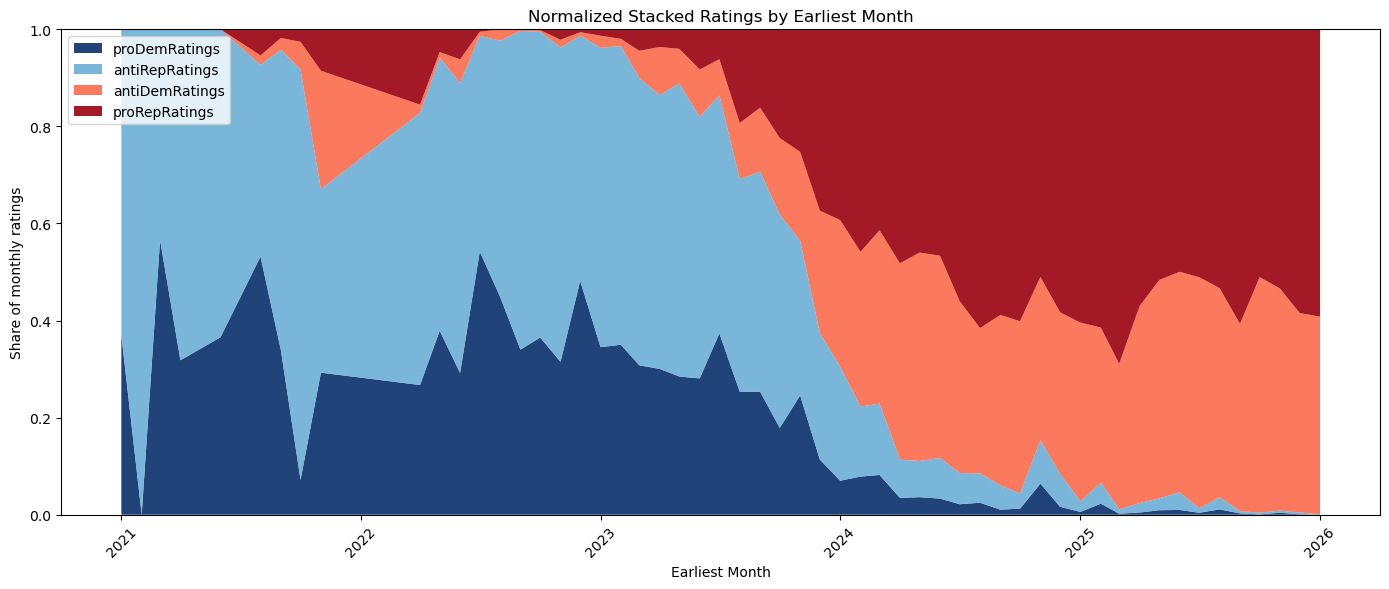

In [55]:
# Ensure month order
ratings_prop = ratings_prop.sort_values("start_month")

# Normalized stacked chart (each month sums to 1)
plt.figure(figsize=(14, 6))
plt.stackplot(
    ratings_prop["start_month"],
    ratings_prop["proDemRatings_prop"],
    ratings_prop["antiRepRatings_prop"],
    ratings_prop["antiDemRatings_prop"],
    ratings_prop["proRepRatings_prop"],
    labels=["proDemRatings", "antiRepRatings", "antiDemRatings", "proRepRatings"],
    colors=["#08306b", "#6baed6", "#fb6a4a", "#99000d"],
    alpha=0.9
)

plt.xlabel("Earliest Month")
plt.ylabel("Share of monthly ratings")
plt.title("Normalized Stacked Ratings by Earliest Month")
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

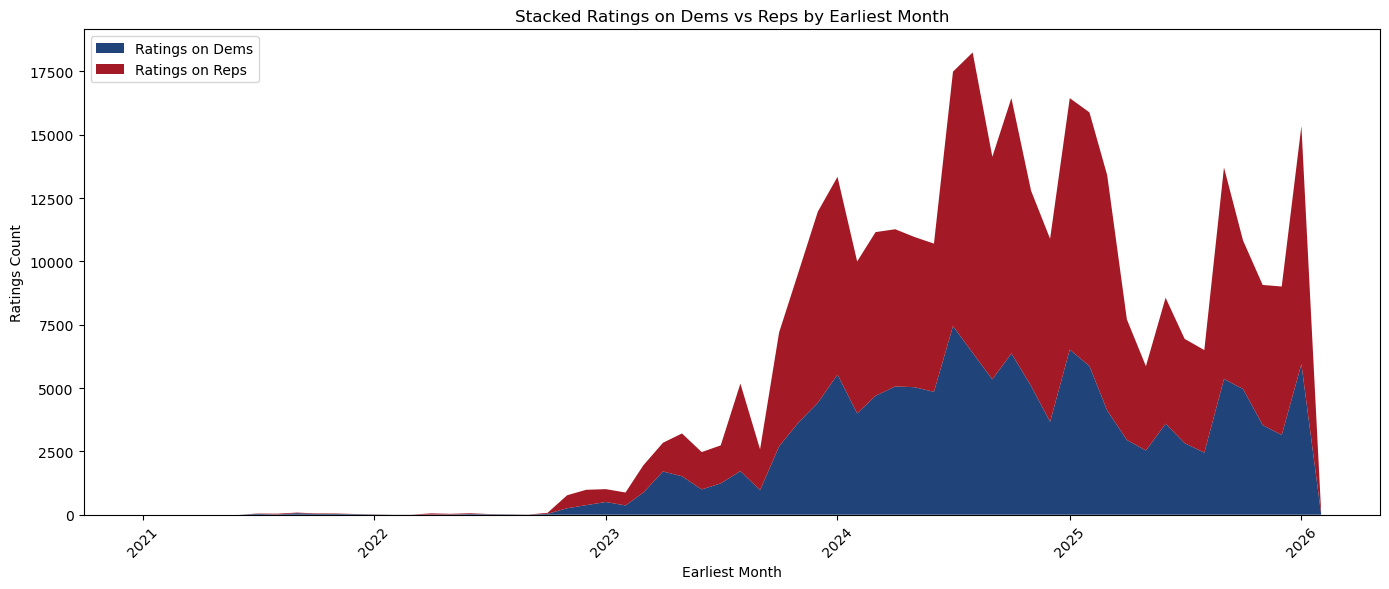

In [52]:
# Aggregate ratingsOnDems and ratingsOnReps by earliest_month from the 'month' DataFrame
ratings_on_both = (
    month.groupby("calendarDate")[["ratingsOnDems", "ratingsOnReps"]]
    .sum()
    .reset_index()
    .rename(columns={"calendarDate": "earliest_month"})
)
ratings_on_both["earliest_month"] = pd.to_datetime(ratings_on_both["earliest_month"])
ratings_on_both["total"] = ratings_on_both["ratingsOnDems"] + ratings_on_both["ratingsOnReps"]
ratings_on_both = ratings_on_both.sort_values("earliest_month")



plt.figure(figsize=(14, 6))
plt.stackplot(
    ratings_on_both["earliest_month"],
    ratings_on_both["ratingsOnDems"],
    ratings_on_both["ratingsOnReps"],
    labels=["Ratings on Dems", "Ratings on Reps"],
    colors=["#08306b", "#99000d"],
    alpha=0.9
)
plt.xlabel("Earliest Month")
plt.ylabel("Ratings Count")
plt.title("Stacked Ratings on Dems vs Reps by Earliest Month")
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

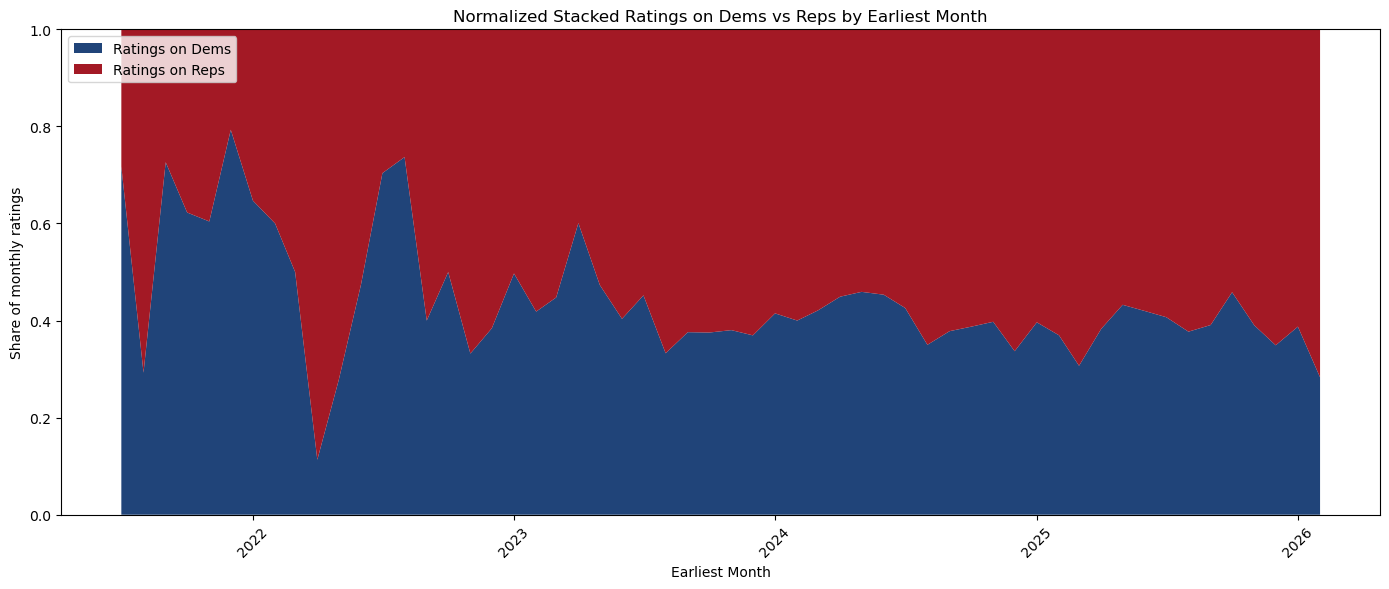

In [56]:
# Normalize ratingsOnDems vs ratingsOnReps to monthly shares
ratings_on_both_norm = ratings_on_both.loc[ratings_on_both["total"] > 0].copy()
ratings_on_both_norm["ratingsOnDems_prop"] = (
    ratings_on_both_norm["ratingsOnDems"] / ratings_on_both_norm["total"]
)
ratings_on_both_norm["ratingsOnReps_prop"] = (
    ratings_on_both_norm["ratingsOnReps"] / ratings_on_both_norm["total"]
)
ratings_on_both_norm = ratings_on_both_norm.sort_values("earliest_month")

plt.figure(figsize=(14, 6))
plt.stackplot(
    ratings_on_both_norm["earliest_month"],
    ratings_on_both_norm["ratingsOnDems_prop"],
    ratings_on_both_norm["ratingsOnReps_prop"],
    labels=["Ratings on Dems", "Ratings on Reps"],
    colors=["#08306b", "#99000d"],
    alpha=0.9
)
plt.xlabel("Earliest Month")
plt.ylabel("Share of monthly ratings")
plt.title("Normalized Stacked Ratings on Dems vs Reps by Earliest Month")
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- take proportions of individual users before aggregating by month 
- to account for users with more/less ratings
- also check notes
- also check ratings/notes on by calendar month instead of start_month
- 